# Статистическая проверка гипотезы: MILP vs Эвристики (Avalanche, Snowball)

Данный ноутбук предназначен для анализа результатов вычислительного эксперимента. 
Предполагается, что прогоны алгоритмов уже выполнены, а результаты сохранены в табличном виде (например, CSV).

**Формулировка гипотезы:**
Если реализовать и корректно верифицировать MILP-модель задачи RPML, то на сопоставимых инстансах суммарные затраты на погашение долгов будут систематически ниже, чем при использовании эвристик Debt Avalanche и Debt Snowball.

**Нулевая гипотеза ($H_0$):** Медианная разность затрат равна нулю (MILP не дает улучшений).
**Альтернативная гипотеза ($H_1$):** Медианная разность меньше нуля (MILP дает строго меньшие суммарные затраты).

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

## 1. Загрузка и подготовка данных

Ожидается файл с колонками: `instance_name`, `milp_cost`, `avalanche_cost`, `snowball_cost`, `milp_status`.
Для корректного сравнения фильтруем только те инстансы, где MILP нашел глобальный оптимум (`OPTIMAL`).

In [14]:
os.path.exists("./tmp/experiment_results.csv")

True

In [15]:
DATA_PATH = "./tmp/experiment_results.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    raise FileDoesNotExists(f"Файл {DATA_PATH} не найден!")

# Фильтрация по статусу OPTIMAL
df_opt = df[df['status'] == 'OPTIMAL'].copy()
print(f"Всего инстансов: {len(df)}")
print(f"Инстансов со статусом OPTIMAL: {len(df_opt)}")

# Вычисление парных разностей (Cost_MILP - Cost_Heuristic)
# Отрицательное значение означает, что MILP выгоднее (затраты меньше)
df_opt['delta_avalanche'] = df_opt['milp_cost'] - df_opt['avalanche_cost']
df_opt['delta_snowball'] = df_opt['milp_cost'] - df_opt['snowball_cost']

Всего инстансов: 30
Инстансов со статусом OPTIMAL: 30


## 2. Описательная статистика

Анализ базовых метрик распределения разностей.

In [16]:
summary_stats = pd.DataFrame({
    'MILP vs Avalanche': df_opt['delta_avalanche'].describe(),
    'MILP vs Snowball': df_opt['delta_snowball'].describe()
}).T

display(summary_stats.round(2))

,count,mean,std,min,25%,50%,75%,max
MILP vs Avalanche,30.0,-21189.46,46372.13,-244239.27,-19779.20,-7492.34,-0.00,0.0
MILP vs Snowball,30.0,-53191.83,117689.11,-621212.97,-49068.41,-19271.05,-1872.16,0.0


## 3. Визуальный анализ

### 3.1 Диаграмма рассеяния (Scatter Plot)
Сравнение абсолютных значений затрат. Линия $Y = X$ обозначает равенство методов. Точки ниже линии означают превосходство MILP.

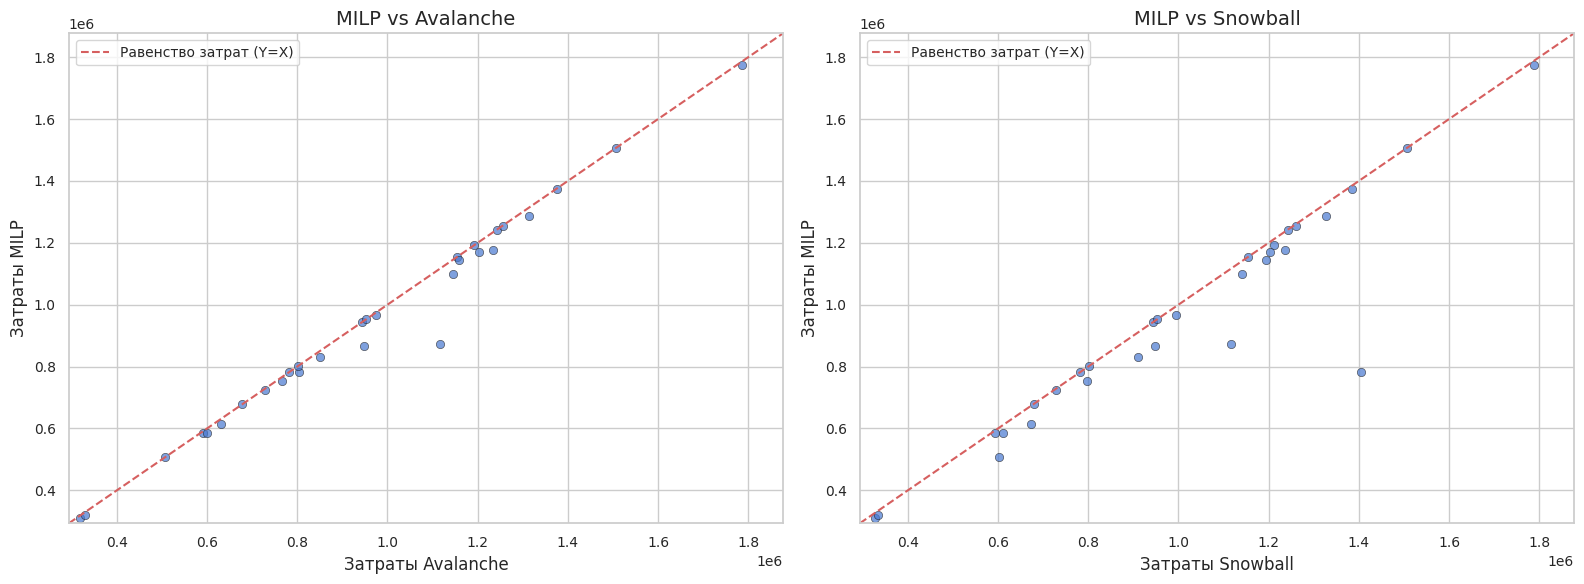

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

max_val = max(df_opt[['milp_cost', 'avalanche_cost', 'snowball_cost']].max()) * 1.05
min_val = min(df_opt[['milp_cost', 'avalanche_cost', 'snowball_cost']].min()) * 0.95

def plot_scatter(ax, x_col, y_col, title, x_label):
    sns.scatterplot(data=df_opt, x=x_col, y=y_col, ax=ax, alpha=0.7, edgecolor='k')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Равенство затрат (Y=X)')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Затраты MILP")
    ax.legend()
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

plot_scatter(axes[0], 'avalanche_cost', 'milp_cost', 'MILP vs Avalanche', 'Затраты Avalanche')
plot_scatter(axes[1], 'snowball_cost', 'milp_cost', 'MILP vs Snowball', 'Затраты Snowball')

plt.tight_layout()
plt.show()

### 3.2 Распределение разностей (Boxplot и Гистограмма)
Анализ формы распределения $\Delta$ для выбора корректного статистического критерия.

/tmp/ipykernel_60745/3497687513.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['MILP - Avalanche', 'MILP - Snowball'])


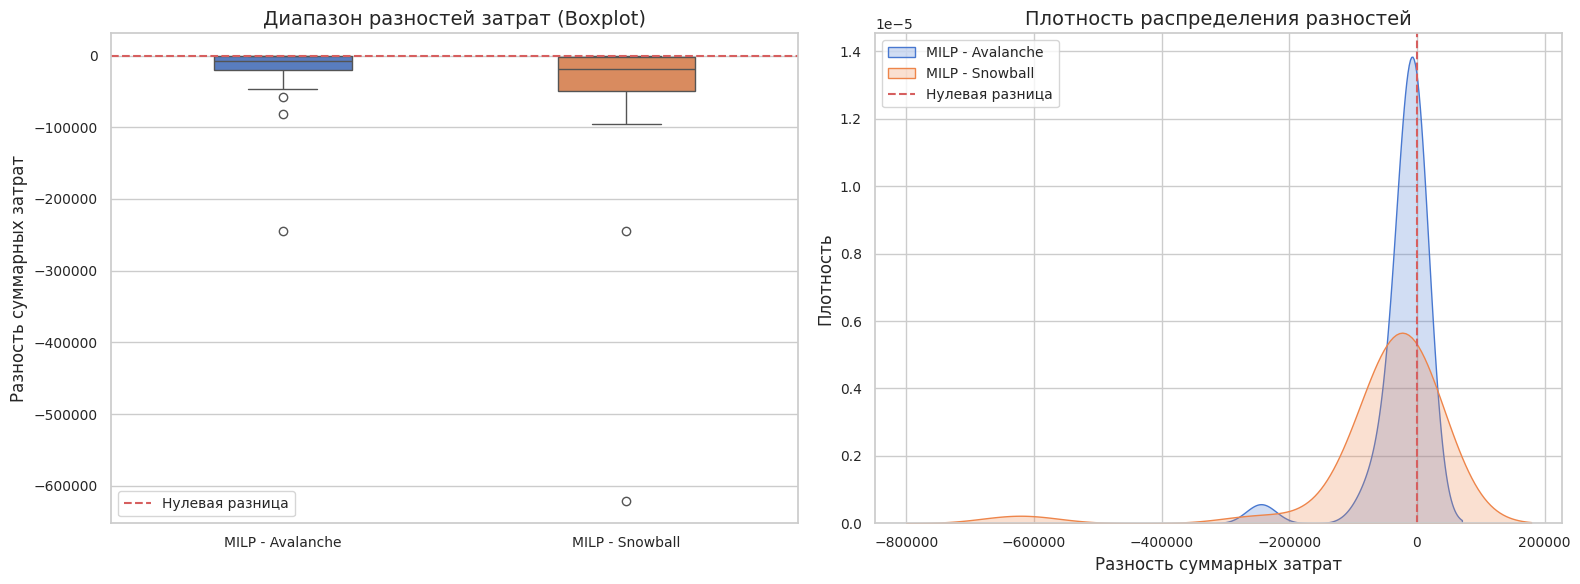

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=df_opt[['delta_avalanche', 'delta_snowball']], ax=axes[0], width=0.4)
axes[0].axhline(0, color='r', linestyle='--', label='Нулевая разница')
axes[0].set_xticklabels(['MILP - Avalanche', 'MILP - Snowball'])
axes[0].set_ylabel('Разность суммарных затрат')
axes[0].set_title('Диапазон разностей затрат (Boxplot)')
axes[0].legend()

# KDE / Histogram
sns.kdeplot(data=df_opt, x='delta_avalanche', ax=axes[1], fill=True, label='MILP - Avalanche')
sns.kdeplot(data=df_opt, x='delta_snowball', ax=axes[1], fill=True, label='MILP - Snowball')
axes[1].axvline(0, color='r', linestyle='--', label='Нулевая разница')
axes[1].set_xlabel('Разность суммарных затрат')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Плотность распределения разностей')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Статистическое тестирование

**Шаг 1. Проверка на нормальность (Критерий Шапиро-Уилка)**
Если $p < 0.05$, распределение значимо отличается от нормального. В таком случае основным критерием становится непараметрический тест Вилкоксона.

**Шаг 2. Односторонний парный тест Вилкоксона**
Проверяет гипотезу о том, что медиана разностей меньше нуля.

**Шаг 3. Односторонний парный t-test**
Применяется как дополнительная проверка устойчивости (robustness check).

In [19]:
def run_statistical_tests(delta_series, name):
    print(f"\n{'='*50}")
    print(f"Анализ для: {name}")
    print(f"{'='*50}")
    
    # Проверка на нормальность
    stat_shapiro, p_shapiro = stats.shapiro(delta_series)
    is_normal = p_shapiro >= 0.05
    print(f"[Шапиро-Уилк] p-value = {p_shapiro:.4e} -> Распределение {'НОРМАЛЬНОЕ' if is_normal else 'НЕ НОРМАЛЬНОЕ'}")
    
    # Тест Вилкоксона (односторонний: alternative='less' означает delta < 0)
    stat_wilcoxon, p_wilcoxon = stats.wilcoxon(delta_series, alternative='less')
    print(f"[Вилкоксон]   p-value = {p_wilcoxon:.4e} -> ", end="")
    if p_wilcoxon < 0.05:
        print("H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.")
    else:
        print("Нет оснований отвергнуть H0.")
        
    # Парный t-test (односторонний)
    stat_ttest, p_ttest = stats.ttest_1samp(delta_series, popmean=0, alternative='less')
    print(f"[t-test]      p-value = {p_ttest:.4e} -> ", end="")
    if p_ttest < 0.05:
        print("H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.")
    else:
        print("Нет оснований отвергнуть H0.")

run_statistical_tests(df_opt['delta_avalanche'], "MILP vs Avalanche")
run_statistical_tests(df_opt['delta_snowball'], "MILP vs Snowball")


Анализ для: MILP vs Avalanche
[Шапиро-Уилк] p-value = 3.0831e-09 -> Распределение НЕ НОРМАЛЬНОЕ
[Вилкоксон]   p-value = 3.6267e-06 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.
[t-test]      p-value = 9.1039e-03 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.

Анализ для: MILP vs Snowball
[Шапиро-Уилк] p-value = 1.6529e-09 -> Распределение НЕ НОРМАЛЬНОЕ
[Вилкоксон]   p-value = 1.2815e-06 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.
[t-test]      p-value = 9.6943e-03 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.


## 5. Выводы

*(Здесь будут описаны финальные выводы после загрузки реальных данных. Пример структуры:)*

1. **Качество решений:** В $X\%$ случаев MILP нашел решение с меньшими суммарными затратами по сравнению с эвристиками.
2. **Статистическая значимость:** Тест Вилкоксона показал $p < 0.05$, что подтверждает статистическую значимость преимуществ MILP-модели.
3. **Распределение разностей:** Анализ распределения показал, что выигрыш от использования MILP варьируется от $A$ до $B$ условных единиц.